In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Custom settings
plt.style.use('classic')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['figure.dpi'] = 100


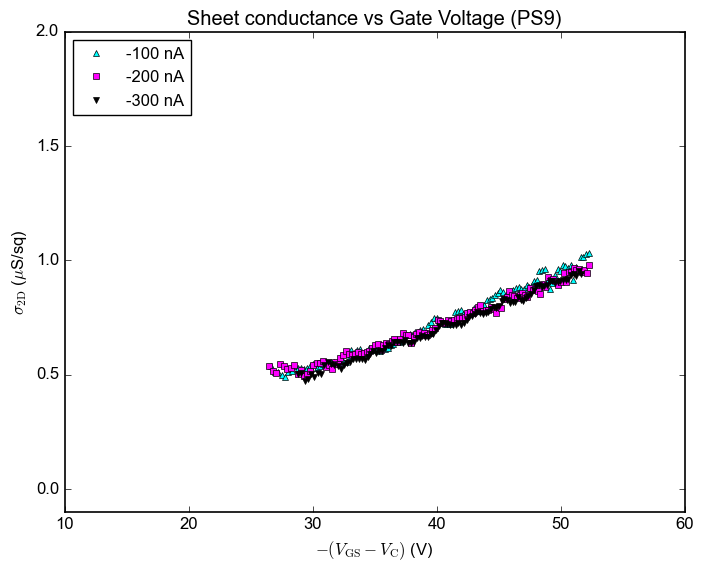

In [8]:
data1 = np.loadtxt("./Data-vdP/20262504001.dat")
data2 = np.loadtxt("./Data-vdP/20262504002.dat")
data3 = np.loadtxt("./Data-vdP/20262504003.dat")

datasets_IDS_VDS = [
    ("-100 nA", data1, 'cyan', '^'),
    ("-200 nA", data2, 'magenta', 's'),
    ("-300 nA", data3, 'black', 'v'),
]
for label, data, color, marker in datasets_IDS_VDS:
    V_GS = data[:, 0]
    I_DS = data[:, 2]
    V_DS = data[:, 3]
    V_C = 0.5*(data[:, 4] + data[:, 5])
    V_12 = data[:, 6]
    sigma = data[:, 7]
    plt.plot(-(V_GS - V_C), sigma*1e6, label=label, color=color, marker=marker, linestyle='None', markersize=5, markevery=1)





plt.xlabel(r"$-(V_\text{GS} - V_\text{C})$ (V)")
plt.ylabel(r"$\sigma_\text{2D}$ ($\mu$S/sq)")
plt.xlim(10, 60)
plt.ylim(-0.1, 2)
plt.legend(frameon=True, loc='upper left', numpoints=1, fontsize=12)
plt.title("Sheet conductance vs Gate Voltage (PS9)")
plt.show()

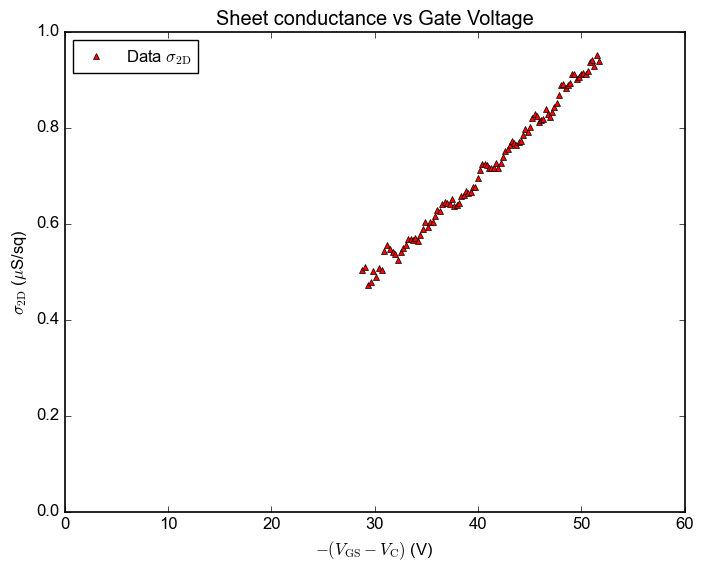

In [9]:
data = np.loadtxt("./Data-vdP/20262504003.dat")

V_GS = data[:, 0]
I_DS = data[:, 2]
V_DS = data[:, 3]
V_C = 0.5*(data[:, 4] + data[:, 5])
V_12 = data[:, 6]
sigma = data[:, 7]
plt.plot(-(V_GS - V_C), sigma*1e6, '^', label=r'Data $\sigma_\text{2D}$', color='red', markersize=5, markevery=1)




plt.xlabel(r"$-(V_\text{GS} - V_\text{C})$ (V)")
plt.ylabel(r"$\sigma_\text{2D}$ ($\mu$S/sq)")
plt.xlim(0, 60)
plt.ylim(0.0, 1.0)
plt.legend(frameon=True, loc='upper left', numpoints=1,fontsize=12)
plt.title("Sheet conductance vs Gate Voltage")
plt.show()

a = 2.05e-08 ± 1.94e-10
b = -1.21e-07 ± 7.99e-09
R^2 = 0.991
V_T = (-5.9 ± 0.393) V
mu_int = (2.53 ± 0.0239) cm^2/Vs


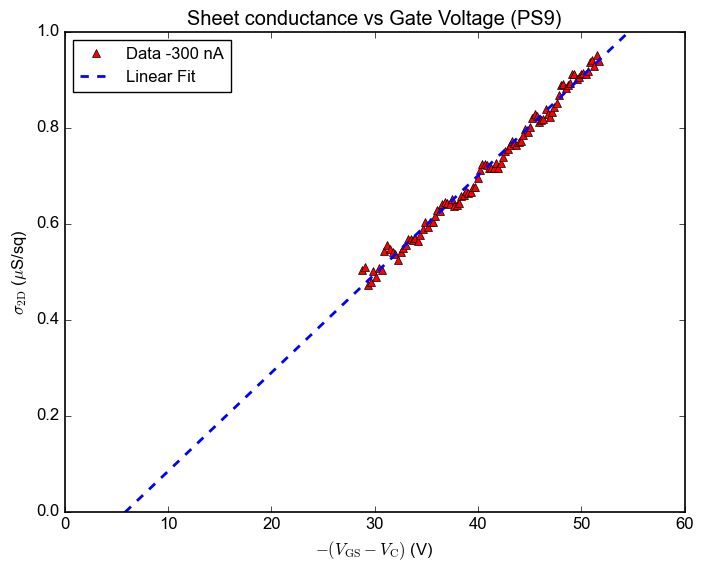

In [10]:
C = 2.6e-9  # F
A = 32e-6  # m^2
Ci = C / A  # F/m^2
V_del = -(V_GS - V_C)

def func(x, a, b):
    return a * x + b

popt, pcov = curve_fit(func, V_del, sigma)
sigma_fit = func(V_del, *popt)
a, b = popt

# Coefficient of determination
ss_res = np.sum((sigma - sigma_fit) ** 2)
ss_tot = np.sum((sigma - np.mean(sigma)) ** 2)
r2 = 1 - (ss_res / ss_tot)

# 1-sigma parameter uncertainties from covariance matrix
perr = np.sqrt(np.diag(pcov))
a_err, b_err = perr
V_T_fit = b / a
V_T_err = abs(V_T_fit) * np.sqrt((b_err / b) ** 2 + (a_err / a) ** 2)
mu_fit = a / Ci * 1e4
mu_err = abs(mu_fit * a_err / a)

print(f"a = {a:.3g} ± {a_err:.3g}")
print(f"b = {b:.3g} ± {b_err:.3g}")
print(f"R^2 = {r2:.3f}")

print(f"V_T = ({V_T_fit:.3g} ± {V_T_err:.3g}) V")
print(f"mu_int = ({mu_fit:.3g} ± {mu_err:.3g}) cm^2/Vs")

x = np.linspace(0, 60, 100)
plt.plot(-(V_GS - V_C), sigma*1e6, '^', label=r'Data -300 nA', color='red', markersize=6, markevery=1)
plt.plot(x, func(x, *popt) * 1e6, lw=2, label='Linear Fit', color='blue', linestyle='--')
plt.xlabel(r"$-(V_\text{GS} - V_\text{C})$ (V)")
plt.ylabel(r"$\sigma_\text{2D}$ ($\mu$S/sq)")
plt.xlim(0, 60)
plt.ylim(0, 1.0)
plt.legend(frameon=True, loc='upper left', numpoints=1, fontsize=12)
plt.title("Sheet conductance vs Gate Voltage (PS9)")
# plt.savefig("conductance_PS9.eps", format='eps', bbox_inches='tight')
plt.show()

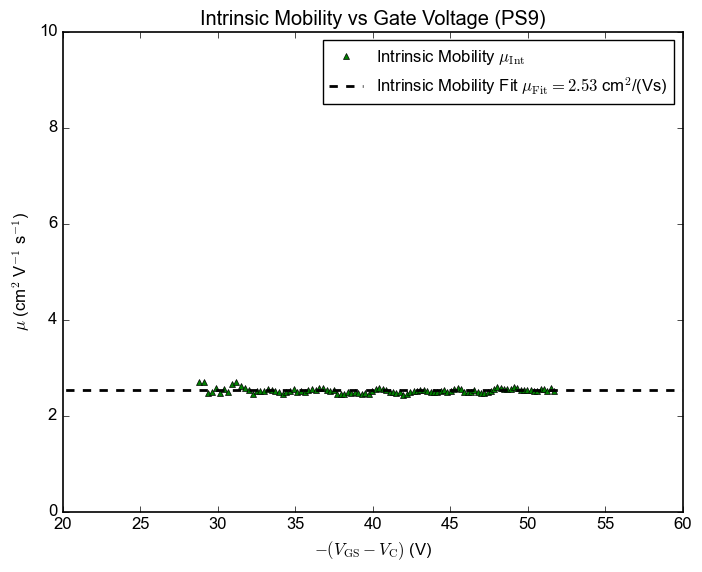

In [11]:
mu_int = -sigma / (Ci * (V_GS  - V_T_fit - V_C)) * 1e4  # Convert to cm^2/Vs
mu_C = -sigma / (Ci * (V_GS - V_T_fit - V_DS/2)) * 1e4  # Overestimates mobility
mu_program = -data[:,9]

plt.plot(V_del, mu_int, label=r'Intrinsic Mobility $\mu_\text{Int}$', color='green', marker='^', markersize=5, markevery=1, linestyle='None')
# plt.plot(V_del, mu_C, label=r'Overestimated Mobility $\mu_\text{C}$', color='blue', marker='o', markersize=5, markevery=1, linestyle='None')
# plt.plot(V_del, mu_program, label=r'Program Mobility $\mu_\text{Program}$', color='orange', marker='s', markersize=5, markevery=1, linestyle='None')
plt.plot(x, np.ones_like(x) * mu_fit, lw=2, label=rf'Intrinsic Mobility Fit $\mu_\text{{Fit}} = {mu_fit:.2f}$ cm$^2$/(Vs)', color='black', linestyle='--')
plt.xlabel(r"$-(V_\text{GS} - V_\text{C})$ (V)")
plt.ylabel(r"$\mu$ (cm$^2$ V$^{-1}$ s$^{-1}$)")
plt.xlim(20, 60)
plt.ylim(0, 10)
plt.legend(frameon=True, loc='upper right', numpoints=1, fontsize=12)
plt.title("Intrinsic Mobility vs Gate Voltage (PS9)")
# plt.savefig("mobility_PS9.eps", format='eps', bbox_inches='tight')
plt.show()

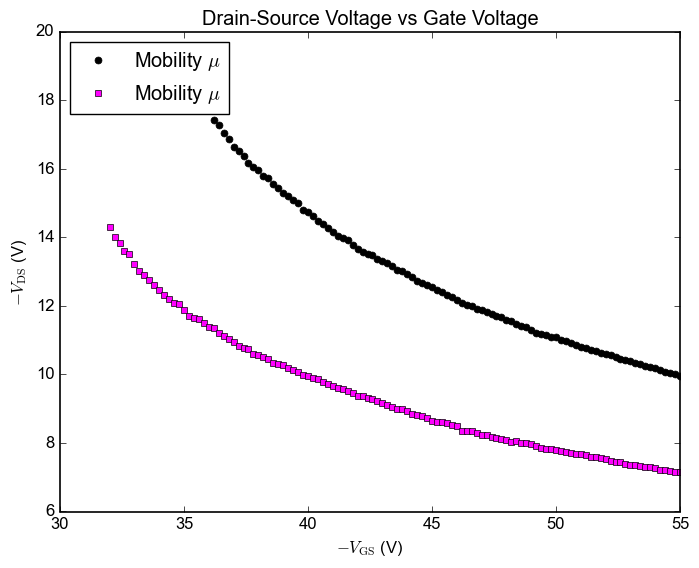

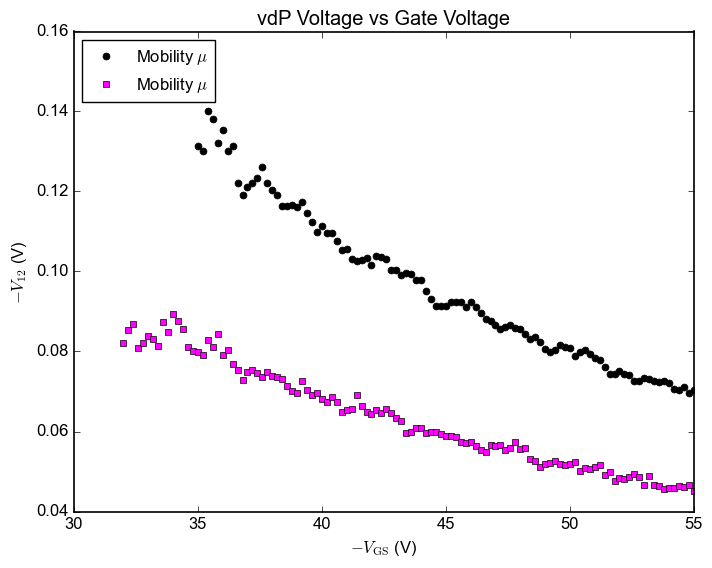

In [12]:
datasets_VDS_VGS = [
    ("300 nA", data3, 'black', 'o'),
    ("200 nA", data2, 'magenta', 's'),
    ]

for label, data, color, marker in datasets_VDS_VGS:
    V_GS = data[:, 0]
    V_DS = data[:, 3]
    plt.plot(-V_GS, -V_DS, label=r'Mobility $\mu$', color=color, marker=marker, markersize=5, markevery=1, linestyle='None')

plt.xlabel(r"$-V_\text{GS}$ (V)")
plt.ylabel(r"$-V_\text{DS}$ (V)")
# plt.xlim(20, 60)
# plt.ylim(0, 10)
plt.legend(frameon=True, loc='upper left', numpoints=1)
plt.title("Drain-Source Voltage vs Gate Voltage")
plt.show()

for label, data, color, marker in datasets_VDS_VGS:
    V_GS = data[:, 0]
    V_12 = data[:, 6]
    plt.plot(-V_GS, -V_12, label=r'Mobility $\mu$', color=color, marker=marker, markersize=5, markevery=1, linestyle='None')

plt.xlabel(r"$-V_\text{GS}$ (V)")
plt.ylabel(r"$-V_\text{12}$ (V)")
# plt.xlim(20, 60)
# plt.ylim(0, 10)
plt.legend(frameon=True, loc='upper left', numpoints=1, fontsize=12)
plt.title("vdP Voltage vs Gate Voltage")
plt.show()